In [2]:
import sys
import os
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from starcat import BuildConsensusReference, starCAT

/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/minicon

In [3]:

# 1. 读取数据
adata = sc.read_h5ad(
    "/sibcb1/bioinformatics/yangyue/project/241120_TFs/data/COVID_GSE145926_allcell.h5ad"
)
adata

AnnData object with n_obs × n_vars = 65813 × 23916
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'ID', 'sample', 'sample_new', 'group', 'group1', 'disease', 'nCoV_mean', 'nFeature_RNA_low', 'nFeature_RNA_high', 'before', 'filter', 'integrated_snn_res.1.2', 'seurat_clusters', 'idt', 'hasnCoV', 'cluster', 'celltype', 'barcode'
    obsm: 'X_pca', 'X_tsne', 'X_umap'

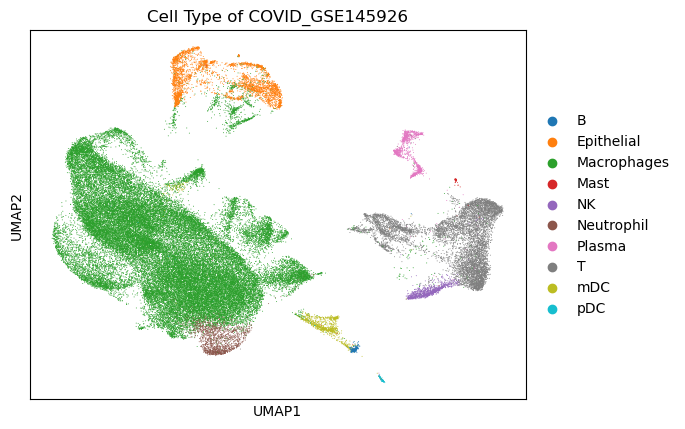

In [5]:
sc.pl.umap(adata, color='celltype', title='Cell Type of COVID_GSE145926')

In [7]:
query_adata = adata[adata.obs['celltype'] == 'Neutrophil'].copy()
query_adata

AnnData object with n_obs × n_vars = 1607 × 23916
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'ID', 'sample', 'sample_new', 'group', 'group1', 'disease', 'nCoV_mean', 'nFeature_RNA_low', 'nFeature_RNA_high', 'before', 'filter', 'integrated_snn_res.1.2', 'seurat_clusters', 'idt', 'hasnCoV', 'cluster', 'celltype', 'barcode'
    uns: 'celltype_colors'
    obsm: 'X_pca', 'X_tsne', 'X_umap'

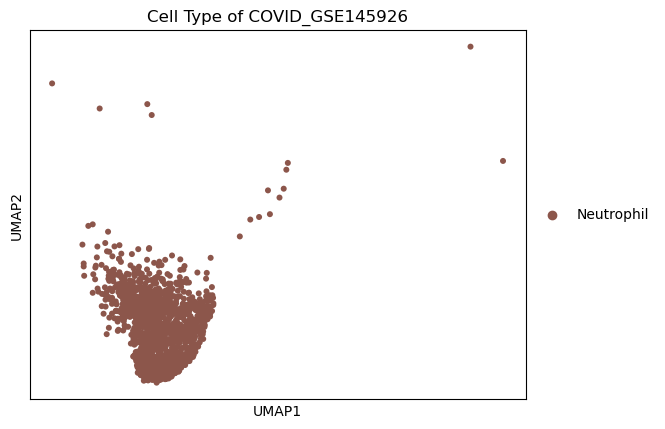

In [8]:
sc.pl.umap(query_adata, color='celltype', title='Cell Type of COVID_GSE145926')

In [9]:
# 查看 group 列包含的所有类别
print(query_adata.obs['group'].unique().tolist())
# 1. 定义您想挑出的组名列表
target_groups = ['HC', 'M', 'S']  # 请根据第一步的输出结果修改这里！

# 2. 提取子集并生成一个新的 AnnData 对象
# 注意结尾加上 .copy()，避免修改子集时影响原数据
control_adata = query_adata[query_adata.obs['group'].isin(target_groups)].copy()

# 3. 查看提取后的结果
print(f"提取完成！剩余细胞数: {control_adata.n_obs}")
print("包含的组别:", control_adata.obs['group'].unique().tolist())

['M', 'S']
提取完成！剩余细胞数: 1607
包含的组别: ['M', 'S']
